# SRL-NER Sirah — S2 (Adaptive Threshold 0.9→0.7 + Class Weight)

# BERT Percobaan 1 (35% train and 65% unlabelled)

## Install dependency

In [1]:
# Colab sudah punya transformers/datasets/torch — cukup upgrade
!pip install -q -U transformers accelerate seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 166.2 MB/s eta 0:00:00


In [2]:
pip install tqdm -q

In [3]:
pip install -U accelerate>=0.21.0' -q

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [4]:
pip install -U transformers[torch] -q

In [5]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.8 MB/s eta 0:00:00


In [6]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, TrainingArguments, Trainer, DataCollatorForTokenClassification, AutoModelForTokenClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from shutil import rmtree
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import os

# seqeval = entity-level NER metrics (fix G). Install once:  pip install seqeval
try:
    from seqeval.metrics import classification_report as seq_classification_report
    from seqeval.metrics import f1_score as seq_f1_score
    from seqeval.metrics import precision_score as seq_precision_score
    from seqeval.metrics import recall_score as seq_recall_score
    _HAS_SEQEVAL = True
except ImportError:
    _HAS_SEQEVAL = False
    print("[warn] seqeval tidak tersedia — jalankan `pip install seqeval` untuk metric entity-level")


[warn] seqeval tidak tersedia — jalankan `pip install seqeval` untuk metric entity-level


## Load and prepare datasets

In [7]:
os.getcwd()

'/content'

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
_name = 'bert-only'
_type = 'sirah-ner'
experiment_name = f'{_name}-{_type}-S2'

import os
# === Colab paths (Google Drive) ===
# Upload train.csv / test.csv / unlabelled.csv ke folder Drive berikut:
dataset_dir = '/content/drive/MyDrive/TA-Sirah'
root_dir    = '/content/drive/MyDrive/TA-Sirah/output'
model_dir   = os.path.join(root_dir, 'models')
eval_dir    = os.path.join(root_dir, 'evaluation')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(eval_dir,  exist_ok=True)

In [10]:
df_train = pd.read_csv(os.path.join(dataset_dir, 'train.csv'))
df_train["token"] = df_train["token"].apply(str)
df_train["label"] = df_train["label"].apply(lambda x: x.replace("-", "_"))
df_train.loc[df_train[df_train.isna().any(axis=1)].index, 'token'] = 'nan'

In [11]:
# === Smoke test: cek GPU & file ===
import torch, os
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("!! GPU tidak aktif. Runtime > Change runtime type > T4 GPU")

for f in ['train.csv', 'test.csv', 'unlabelled.csv']:
    fp = os.path.join(dataset_dir, f)
    print(f"{f:<16} ->", 'OK' if os.path.exists(fp) else 'MISSING', fp)


CUDA available : True
GPU            : NVIDIA H100 80GB HBM3
train.csv        -> OK /content/drive/MyDrive/TA-Sirah/train.csv
test.csv         -> OK /content/drive/MyDrive/TA-Sirah/test.csv
unlabelled.csv   -> OK /content/drive/MyDrive/TA-Sirah/unlabelled.csv


In [12]:
# # Cek indeks baris dengan NaN di kolom 'token'
# nan_token_indices = df_train[df_train["token"].isna()].index
# print("Indeks baris dengan NaN di kolom 'token':", nan_token_indices)

# # Cek indeks baris dengan NaN di kolom 'entity'
# nan_entity_indices = df_train[df_train["label"].isna()].index
# print("Indeks baris dengan NaN di kolom 'label':", nan_entity_indices)


In [13]:
label_list = sorted(df_train['label'].unique(),key=lambda name: (name[1:], name[0]))
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {v: k for k, v in id2label.items()}

id2label

{0: 'O',
 1: 'B_EVENT',
 2: 'I_EVENT',
 3: 'B_LOCATION',
 4: 'I_LOCATION',
 5: 'B_PERSON',
 6: 'I_PERSON',
 7: 'B_TIME',
 8: 'I_TIME'}

In [14]:
# === [S2] Compute class weights (inverse frequency) ===
import torch
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

labels_in_train = df_train["label"].dropna().tolist()
label_counts = Counter(labels_in_train)
print("Distribusi label train:")
total_lbl = sum(label_counts.values())
for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / total_lbl
    print(f"  {lbl:<14} {cnt:>6}  {pct:>5.2f}%")

import numpy as np
classes_arr = sorted(label_counts.keys(), key=lambda x: label2id[x])
y_arr = labels_in_train
weights_np = compute_class_weight('balanced', classes=np.array(classes_arr), y=y_arr)

# Clipping untuk stabilitas — bobot ekstrem (>50x) bisa bikin training NaN
WEIGHT_CLIP_MAX = 50.0
weights_np_clipped = [min(float(w), WEIGHT_CLIP_MAX) for w in weights_np]

class_weights_tensor = torch.zeros(len(label_list), dtype=torch.float)
for lbl, w in zip(classes_arr, weights_np_clipped):
    class_weights_tensor[label2id[lbl]] = w

print(f"\nClass weights (clipped to max {WEIGHT_CLIP_MAX:.0f}):")
for lbl, w in zip(classes_arr, weights_np_clipped):
    print(f"  {lbl:<14} {w:>7.2f}")


Distribusi label train:
  O               95302  92.63%
  B_PERSON         2884   2.80%
  I_PERSON         2675   2.60%
  B_LOCATION        985   0.96%
  I_TIME            433   0.42%
  B_TIME            233   0.23%
  I_EVENT           156   0.15%
  B_EVENT           144   0.14%
  I_LOCATION         72   0.07%

Class weights (clipped to max 50):
  O                 0.12
  B_EVENT          50.00
  I_EVENT          50.00
  B_LOCATION       11.61
  I_LOCATION       50.00
  B_PERSON          3.96
  I_PERSON          4.27
  B_TIME           49.06
  I_TIME           26.40


## Tokenize and split dataset into train and validation

In [15]:
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased", model_max_length=512)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples['tokens'], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples['label']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


def df_to_dataset_for_model(df: pd.DataFrame, val_text_ids: list | None = None):
    """
    Preserves Bu Diana's logic (group by text_id → tokens list → label list → HF Dataset).

    FIX B: supports fixed validation split via `val_text_ids`.
    - If val_text_ids is None: falls back to random 80/20 (Bu Diana default).
    - If provided: val = text_ids in the list, train = everything else.
      This keeps the validation set stable across iterations so F1 val is comparable.
    """
    df = df.copy(deep=True)
    df["label"] = df["label"].fillna('O')
    df["label"] = df["label"].apply(lambda x: label2id[x])

    tmp_df = df.groupby("text_id")["token"].apply(list).reset_index()
    tmp_df["label"] = df.groupby("text_id")["label"].apply(list).reset_index()["label"]
    tmp_df.columns = ["text_id", "tokens", "label"]

    tmp_list = []
    for i in tmp_df.index:
        tmp_list.append({
            "text_id": tmp_df.loc[i, "text_id"],
            "tokens": tmp_df.loc[i, "tokens"],
            "label":  tmp_df.loc[i, "label"],
        })

    dataset = Dataset.from_list(tmp_list)

    tokenized_dataset = dataset.map(tokenize_and_align_labels,
                                    batched=True,
                                    remove_columns=[c for c in dataset.column_names if c != "text_id"])

    if val_text_ids is None:
        # Bu Diana default: random 80/20
        splits = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
        train_val = DatasetDict({"train": splits["train"], "validation": splits["test"]})
    else:
        val_set  = set(map(str, val_text_ids))
        is_val   = [str(x) in val_set for x in tokenized_dataset["text_id"]]
        val_idx  = [i for i, v in enumerate(is_val) if v]
        trn_idx  = [i for i, v in enumerate(is_val) if not v]
        train_val = DatasetDict({
            "train":      tokenized_dataset.select(trn_idx).remove_columns(["text_id"]),
            "validation": tokenized_dataset.select(val_idx).remove_columns(["text_id"]),
        })

    return train_val


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [16]:
train_val = df_to_dataset_for_model(df_train)
print(train_val)

Map:   0%|          | 0/599 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 479
    })
    validation: Dataset({
        features: ['text_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 120
    })
})


## Begin training base model

In [17]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(pred):
    """Bu Diana: token-level weighted precision / recall / F1 (sklearn)."""
    labels = pred.label_ids
    predictions = np.argmax(pred.predictions, axis=2)

    true_labels      = [[l for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]
    true_predictions = [[p for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]

    flat_true = [item for sub in true_labels      for item in sub]
    flat_pred = [item for sub in true_predictions for item in sub]

    precision, recall, f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, average='weighted', zero_division=0)

    out = {"precision": precision, "recall": recall, "f1": f1}

    # Fix G: entity-level seqeval metrics (used only for logging; Bu Diana's f1 stays as the 'best model' criterion)
    if _HAS_SEQEVAL:
        true_lbl = [[id2label[l] for l in seq] for seq in true_labels]
        pred_lbl = [[id2label[p] for p in seq] for seq in true_predictions]
        try:
            out["seq_f1"]        = seq_f1_score(true_lbl, pred_lbl)
            out["seq_precision"] = seq_precision_score(true_lbl, pred_lbl)
            out["seq_recall"]    = seq_recall_score(true_lbl, pred_lbl)
        except Exception:
            pass
    return out


# === [S2] WeightedTrainer subclass — apply class weights ke CrossEntropyLoss ===
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self._class_weights.to(logits.device) if self._class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight, ignore_index=-100)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def train_model(model_name: str,
                train_dataset: Dataset,
                val_dataset: Dataset,
                model_output_path: str,
                num_train_epochs: int = 10):

    training_args = TrainingArguments(
        output_dir=os.path.join(model_dir, "_trainer_tmp"),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        seed=42,
    )

    def model_init():
        return AutoModelForTokenClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id)

    trainer = WeightedTrainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights_tensor,
    )

    trainer.train()
    trainer.save_model(model_output_path)

    rmtree(os.path.join(model_dir, "_trainer_tmp"), ignore_errors=True)


In [18]:
# --- BIO-aware decoder (Fix A) ---
# Bu Diana's labels are flat (ARG0, ARG1, ...), Sirah's are BIO (B_PERSON, I_PERSON, O).
# We auto-detect from id2label so the same function works in both schemes.
_BIO_SCHEME = any(str(lab).startswith(("B_", "I_")) for lab in id2label.values())


def extract_entities_from_result(tokens, result):
    """
    Map a list of whitespace-separated `tokens` to a list of labels using the
    HF NER pipeline output (`result` = list of {entity_group, start, end, score, word}).
    """
    predicted_entities = []
    current_index = 0
    prev_span_id = None

    for token in tokens:
        hit = None
        for idx, entry in enumerate(result):
            if entry["start"] <= current_index < entry["end"]:
                hit = idx
                break

        if hit is None:
            label = "O"
            prev_span_id = None
        else:
            group = result[hit]["entity_group"]
            if _BIO_SCHEME:
                if group.startswith(("B_", "I_")):
                    label = group
                else:
                    label = f"B_{group}" if hit != prev_span_id else f"I_{group}"
            else:
                label = group
            prev_span_id = hit

        predicted_entities.append(label)
        current_index += len(token) + 1

    return predicted_entities


def filter_threshold(model_path: str,
                     df: pd.DataFrame,
                     threshold: float,
                     output_dir: str,
                     output_filename_prefix: str,
                     sampling_rate: float = 1.0,
                     min_entity_confidence: float | None = None,
                     aggregation_strategy: str = "simple"):
    """
    Run NER on `df`, save above/below xlsx, return retrain df.
    """
    # Cache: only short-circuit if BOTH retrain CSV AND xlsx files exist
    # (otherwise next-iter prep crashes because below xlsx is missing)
    cache_path = os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv")
    above_xlsx = os.path.join(output_dir, f"{output_filename_prefix}-above-{threshold}.xlsx")
    below_xlsx = os.path.join(output_dir, f"{output_filename_prefix}-below-{threshold}.xlsx")
    if os.path.exists(cache_path) and os.path.exists(above_xlsx) and os.path.exists(below_xlsx):
        tmp_df = pd.read_csv(cache_path)
        tmp_df["token"] = tmp_df["token"].apply(str)
        return tmp_df

    ner = pipeline("token-classification",
                   model=model_path,
                   aggregation_strategy=aggregation_strategy)

    above = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    below = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    predicted_above_rows = []

    text_ids = df["text_id"].unique().tolist()
    for text_id in tqdm(text_ids):
        tokens = df[df["text_id"] == text_id]["token"].astype(str).to_list()
        text = " ".join(tokens)
        result = ner(text)

        if len(result) == 0:
            below["text_id"].append(text_id)
            below["text"].append(text)
            below["predicted_label"].append("-")
            below["word"].append("-")
            below["confidence"].append(0)
            continue

        scores = [float(e["score"]) for e in result]
        avg = sum(scores) / len(scores)
        min_score = min(scores)

        passes_min = (min_entity_confidence is None) or (min_score >= min_entity_confidence)

        if avg >= threshold and passes_min:
            predicted_above_rows.append((text_id, tokens,
                                         extract_entities_from_result(tokens, result),
                                         avg))
            for entity in result:
                above["text_id"].append(text_id)
                above["text"].append(text)
                above["predicted_label"].append(entity["entity_group"])
                above["word"].append(entity["word"])
                above["confidence"].append(entity["score"])
        else:
            for entity in result:
                below["text_id"].append(text_id)
                below["text"].append(text)
                below["predicted_label"].append(entity["entity_group"])
                below["word"].append(entity["word"])
                below["confidence"].append(entity["score"])

    if 0 < sampling_rate < 1.0 and predicted_above_rows:
        predicted_above_rows.sort(key=lambda r: r[3], reverse=True)
        keep = max(1, int(round(len(predicted_above_rows) * sampling_rate)))
        predicted_above_rows = predicted_above_rows[:keep]
        kept_ids = {r[0] for r in predicted_above_rows}
        above = {k: [v for v, tid in zip(vals, above["text_id"]) if tid in kept_ids]
                 for k, vals in above.items()}

    above_df = pd.DataFrame(above)
    below_df = pd.DataFrame(below)

    # ALWAYS save xlsx (next-iter loader needs them)
    above_df.to_excel(above_xlsx)
    below_df.to_excel(below_xlsx)

    print(f"Above {threshold}: {len(above_df['text_id'].unique()) if len(above_df) else 0} sentences "
          f"(sampling_rate={sampling_rate}, min_entity_conf={min_entity_confidence})")
    print(f"Below {threshold}: {len(below_df['text_id'].unique()) if len(below_df) else 0} sentences")

    retrain_rows = []
    for text_id, toks, labs, _avg in predicted_above_rows:
        for t, lab in zip(toks, labs):
            retrain_rows.append({"text_id": text_id, "token": t, "label": lab})
    retrain_df = pd.DataFrame(retrain_rows, columns=["text_id", "token", "label"])

    retrain_df.to_csv(cache_path, index=False)
    return retrain_df


def reconstruct_unlabelled_from_below(below_xlsx_path: str) -> pd.DataFrame:
    """
    Rebuild token-level df from the `text` column. Returns empty df if file
    is empty or missing required columns (self-training converged).
    """
    df = pd.read_excel(below_xlsx_path)
    if len(df) == 0 or "text_id" not in df.columns:
        return pd.DataFrame(columns=["text_id", "token"])
    df = df.drop_duplicates(subset=["text_id"])[["text_id", "text"]].reset_index(drop=True)
    rows = []
    for _, r in df.iterrows():
        for tok in str(r["text"]).split():
            rows.append({"text_id": r["text_id"], "token": tok})
    return pd.DataFrame(rows, columns=["text_id", "token"])


## Iterative pseudo-labelling (threshold=0.9)

Blok di bawah menggantikan 6 pasang cell manual (predict → retrain) jadi satu for-loop,
dengan parameter yang bisa ditune sesuai panduan analyticsvidhya:

| Knob | Default (Bu Diana) | Alternatif |
|---|---|---|
| `N_ITERATIONS` | 6 | 3–10 |
| `THRESHOLD` | 0.9 | 0.85–0.95 |
| `SAMPLING_RATE` | 1.0 (pakai semua above) | 0.5 (pakai top-50%) |
| `MIN_ENTITY_CONF` | None | 0.85 (reject kalimat dgn entity ragu) |
| `MIN_NEW_SAMPLES` | 0 (no early stop) | 20–50 |
| `AGG_STRATEGY` | "simple" | "first" / "max" (sub-word clean) |

Output yang dihasilkan (sama persis struktur Bu Diana):
- `<prefix>-above-0.9.xlsx`, `<prefix>-below-0.9.xlsx` per iterasi
- `<prefix>-above-0.9-retraining.csv` per iterasi (sudah BIO-correct)
- `<experiment_name>-0.9-iteration-{2..N}/` folder model per iterasi
- `iteration_log.csv` — rekap jumlah above per iterasi (plot ini untuk laporan TA)


In [19]:
# ============================================================
# [S2] Iterative pseudo-labelling loop with ADAPTIVE THRESHOLD
# ============================================================
# - Threshold mulai dari THRESHOLD_INIT (0.9). Kalau jumlah pseudo-label yang
#   lolos < TARGET_MIN_SAMPLES, threshold turun bertahap (0.85, 0.80, ...) sampai
#   dapat cukup atau mencapai THRESHOLD_MIN (0.7). Dropping-only (tidak naik).
# - iter_log mencatat threshold_used per iterasi → bisa di-plot.
# - Inherits S1 (class weights via WeightedTrainer di train_model).

# === Knob baseline (sama dengan E1/S1) ===
N_ITERATIONS    = 6
THRESHOLD       = 0.9        # legacy var untuk reconstruct_unlabelled (path file)
SAMPLING_RATE   = 1.0
MIN_ENTITY_CONF = None
MIN_NEW_SAMPLES = 0
AGG_STRATEGY    = "simple"

# === Knob adaptif S2 ===
THRESHOLD_INIT     = 0.9     # threshold awal tiap iterasi
THRESHOLD_MIN      = 0.7     # batas bawah; tidak akan turun di bawah ini
THRESHOLD_STEP     = 0.05    # langkah penurunan
TARGET_MIN_SAMPLES = 50      # minimal kalimat lolos per iter; kalau < ini, drop threshold

# Stable validation split (fix B)
import random as _random
_seed_ids = sorted(df_train["text_id"].unique().tolist())
_rng = _random.Random(42)
_rng.shuffle(_seed_ids)
_n_val = max(1, int(round(len(_seed_ids) * 0.2)))
VAL_TEXT_IDS = _seed_ids[:_n_val]
print(f"[val split] {len(VAL_TEXT_IDS)} / {len(_seed_ids)} seed text_ids reserved for validation")

# Load unlabelled
df_unlabelled = pd.read_csv(os.path.join(dataset_dir, 'unlabelled.csv'))
df_unlabelled["token"] = df_unlabelled["token"].apply(str)

# Bootstrap: train base model on seed
train_val_base = df_to_dataset_for_model(df_train, val_text_ids=VAL_TEXT_IDS)
print(train_val_base)

train_model(
    model_name="indolem/indobert-base-uncased",
    train_dataset=train_val_base["train"],
    val_dataset=train_val_base["validation"],
    model_output_path=os.path.join(model_dir, f"{experiment_name}-base"),
)

# Iterative loop dengan adaptive threshold
pseudo_dfs = []
iter_log = []
current_unlabelled = df_unlabelled
current_model_name = f"{experiment_name}-base"

for i in range(1, N_ITERATIONS + 1):
    if len(current_unlabelled) == 0:
        print(f"[iter {i}] no unlabelled chunks left -> STOP (self-training converged at iter {i-1})")
        break

    prev_model_path = os.path.join(model_dir, current_model_name)
    base_prefix = experiment_name if i == 1 else f"{experiment_name}-iterative-{i}"

    # === ADAPTIVE: mulai threshold tinggi, turun bertahap kalau kurang ===
    threshold = THRESHOLD_INIT
    prefix = base_prefix
    above_df = filter_threshold(
        model_path=prev_model_path,
        df=current_unlabelled,
        threshold=threshold,
        output_dir=eval_dir,
        output_filename_prefix=prefix,
        sampling_rate=SAMPLING_RATE,
        min_entity_confidence=MIN_ENTITY_CONF,
        aggregation_strategy=AGG_STRATEGY,
    )
    n_above = int(above_df["text_id"].nunique()) if len(above_df) else 0

    while n_above < TARGET_MIN_SAMPLES and threshold > THRESHOLD_MIN:
        threshold = round(threshold - THRESHOLD_STEP, 2)
        prefix = f"{base_prefix}-t{threshold}"  # nama beda biar tidak overwrite cache
        print(f"[iter {i}] only {n_above} above @ {threshold + THRESHOLD_STEP:.2f} -> drop ke {threshold}")
        above_df = filter_threshold(
            model_path=prev_model_path,
            df=current_unlabelled,
            threshold=threshold,
            output_dir=eval_dir,
            output_filename_prefix=prefix,
            sampling_rate=SAMPLING_RATE,
            min_entity_confidence=MIN_ENTITY_CONF,
            aggregation_strategy=AGG_STRATEGY,
        )
        n_above = int(above_df["text_id"].nunique()) if len(above_df) else 0

    print(f"[iter {i}] FINAL threshold={threshold}, above: {n_above} sentences")
    iter_log.append({"iter": i, "threshold_used": threshold, "n_above": n_above})

    if n_above < TARGET_MIN_SAMPLES:
        print(f"[iter {i}] adaptive mentok di {threshold} (still < TARGET_MIN_SAMPLES={TARGET_MIN_SAMPLES}) -> STOP")
        # Tetap include pseudo-label yang ada (bukan zero) sebelum stop
        if n_above > 0:
            pseudo_dfs.append(above_df)
        break

    if MIN_NEW_SAMPLES > 0 and n_above < MIN_NEW_SAMPLES:
        print(f"[iter {i}] early-stop: {n_above} < MIN_NEW_SAMPLES={MIN_NEW_SAMPLES}")
        break

    pseudo_dfs.append(above_df)

    # No retrain after the last iteration (matches Bu Diana)
    if i < N_ITERATIONS:
        new_model_name = f"{experiment_name}-iteration-{i+1}"
        combined = pd.concat([df_train] + pseudo_dfs, ignore_index=True)
        train_val_iter = df_to_dataset_for_model(combined, val_text_ids=VAL_TEXT_IDS)
        print(train_val_iter)

        train_model(
            model_name=prev_model_path,
            train_dataset=train_val_iter["train"],
            val_dataset=train_val_iter["validation"],
            model_output_path=os.path.join(model_dir, new_model_name),
        )
        current_model_name = new_model_name

        # Next-iter unlabelled = below-threshold sentences DARI THRESHOLD YANG DIPAKAI
        below_path = os.path.join(eval_dir, f"{prefix}-below-{threshold}.xlsx")
        current_unlabelled = reconstruct_unlabelled_from_below(below_path)

# Save iter log dengan kolom threshold_used (untuk plot adaptive)
pd.DataFrame(iter_log).to_csv(os.path.join(eval_dir, f"iteration_log_{experiment_name}.csv"), index=False)
print("\nIteration log:")
print(pd.DataFrame(iter_log).to_string(index=False))

# Convenience aliases so downstream eval cells keep their variable names
final_iter = iter_log[-1]["iter"] if iter_log else 0
above_09_df = pseudo_dfs[0] if pseudo_dfs else pd.DataFrame()


[val split] 120 / 599 seed text_ids reserved for validation


Map:   0%|          | 0/599 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 479
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 120
    })
})


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

100%|██████████| 40/40 [00:00<00:00, 97.15it/s]


Above 0.75: 40 sentences (sampling_rate=1.0, min_entity_conf=None)
Below 0.75: 0 sentences
[iter 2] only 40 above @ 0.75 -> drop ke 0.7


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:00<00:00, 95.04it/s]


Above 0.7: 40 sentences (sampling_rate=1.0, min_entity_conf=None)
Below 0.7: 0 sentences
[iter 2] FINAL threshold=0.7, above: 40 sentences
[iter 2] adaptive mentok di 0.7 (still < TARGET_MIN_SAMPLES=50) -> STOP

Iteration log:
 iter  threshold_used  n_above
    1             0.9      197
    2             0.7       40


## Evaluate model performance

In [20]:
def get_predicted_label_on_test_dataset(model_path: str, df: pd.DataFrame):
  # Load model
  ner = pipeline("token-classification",
                 model=model_path,
                 aggregation_strategy="simple")

  predicted = []
  text_ids = df["text_id"].unique().tolist()

  for text_id in tqdm(text_ids):
    tokens = df[df["text_id"] == text_id]["token"].to_list()
    text = " ".join(tokens)
    result = ner(text)

    predicted.extend(extract_entities_from_result(tokens, result))

  df["predicted_label"] = predicted

def get_overall_performance(df: pd.DataFrame):
  # Overall accuracy
  total = len(df)
  correct = (df["label"] == df["predicted_label"]).sum()

  accuracy = (correct / total)

  print("Accuracy:", accuracy)

  # Precision, recall, and F1-score
  y_true = df['label']
  y_pred = df['predicted_label']

  precision = precision_score(y_true, y_pred, average='weighted', labels=label_list)
  recall = recall_score(y_true, y_pred, average='weighted', labels=label_list)
  f1 = f1_score(y_true, y_pred, average='weighted', labels=label_list)

  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

def get_individual_label_score(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  report = classification_report(y_true, y_pred, labels=label_list, output_dict=True)
  return pd.DataFrame(report).transpose()

def get_confusion_matrix(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  cm = confusion_matrix(y_true, y_pred, labels=label_list)
  ax= plt.subplot()
  sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Oranges", vmin=0, vmax=160)  #annot=True to annotate cells, ftm='g' to disable scientific notation

  ax.set_xlabel('Predicted labels')
  ax.set_ylabel('True labels')
  ax.set_title('Confusion Matrix')
  plt.xticks(rotation=270)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(label_list)
  ax.yaxis.set_ticklabels(label_list)

def get_misclassified_report(df: pd.DataFrame, output_path: str):

  misclassified_dict = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label != pred_label:
      misclassified_dict['token'].append(df.loc[i, 'token'])
      misclassified_dict['text_id'].append(text_id)
      misclassified_dict['true_label'].append(true_label)
      misclassified_dict['pred_label'].append(pred_label)
      misclassified_dict['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  misclassified_df = pd.DataFrame.from_dict(misclassified_dict)
  misclassified_df.to_excel(output_path)

In [21]:
def get_correct_and_incorrect_classification(df: pd.DataFrame, output_prefix: str):
  correct = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  incorrect = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label == pred_label:
      correct['token'].append(df.loc[i, 'token'])
      correct['text_id'].append(text_id)
      correct['true_label'].append(true_label)
      correct['pred_label'].append(pred_label)
      correct['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))
    else:
      incorrect['token'].append(df.loc[i, 'token'])
      incorrect['text_id'].append(text_id)
      incorrect['true_label'].append(true_label)
      incorrect['pred_label'].append(pred_label)
      incorrect['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  correct_df = pd.DataFrame.from_dict(correct)
  correct_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-correct.xlsx"))

  incorrect_df = pd.DataFrame.from_dict(incorrect)
  incorrect_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-incorrect.xlsx"))

In [22]:
import re, glob

def find_last_iteration_model(model_dir, experiment_name):
    """Auto-detect highest iteration- folder for this experiment that has config.json."""
    pattern = os.path.join(model_dir, f"{experiment_name}*-iteration-*")
    candidates = []
    for path in glob.glob(pattern):
        m = re.search(r"iteration-(\d+)$", path)
        if m and os.path.exists(os.path.join(path, "config.json")):
            candidates.append((int(m.group(1)), path))
    if not candidates:
        # Fallback ke base model kalau tidak ada iteration folder
        base = os.path.join(model_dir, f"{experiment_name}-base")
        if os.path.exists(os.path.join(base, "config.json")):
            print(f"[auto] tidak ada iteration folder -> fallback ke {base}")
            return base, 0
        raise FileNotFoundError(f"Tidak ada model untuk '{experiment_name}' di {model_dir}")
    candidates.sort(reverse=True)
    last_iter, last_path = candidates[0]
    print(f"[auto] Last iteration model: iter-{last_iter} -> {last_path}")
    return last_path, last_iter


df_test = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test["label"] = df_test["label"].apply(lambda x: x.replace("-", "_"))

LAST_MODEL_PATH, LAST_ITER = find_last_iteration_model(model_dir, experiment_name)

get_predicted_label_on_test_dataset(
    model_path=LAST_MODEL_PATH,
    df=df_test,
)


[auto] Last iteration model: iter-2 -> /content/drive/MyDrive/TA-Sirah/output/models/bert-only-sirah-ner-S2-iteration-2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 258/258 [00:03<00:00, 85.36it/s]


In [23]:
get_overall_performance(df_test)
get_individual_label_score(df_test)

Accuracy: 0.9814136002631703
Precision: 0.9855017092555426
Recall: 0.9814136002631703
F1 Score: 0.9825599752658244


,precision,recall,f1-score,support
O,0.999277,0.981039,0.990074,39449.000000
B_EVENT,0.846154,0.936170,0.888889,47.000000
I_EVENT,0.862745,0.830189,0.846154,53.000000
B_LOCATION,0.763158,0.968820,0.853778,449.000000
I_LOCATION,0.481481,1.000000,0.650000,26.000000
B_PERSON,0.758178,0.994113,0.860262,1189.000000
I_PERSON,0.915017,0.996406,0.953978,1113.000000
B_TIME,0.598361,0.986486,0.744898,74.000000
I_TIME,0.732057,0.968354,0.833787,158.000000
accuracy,0.981414,0.981414,0.981414,0.981414


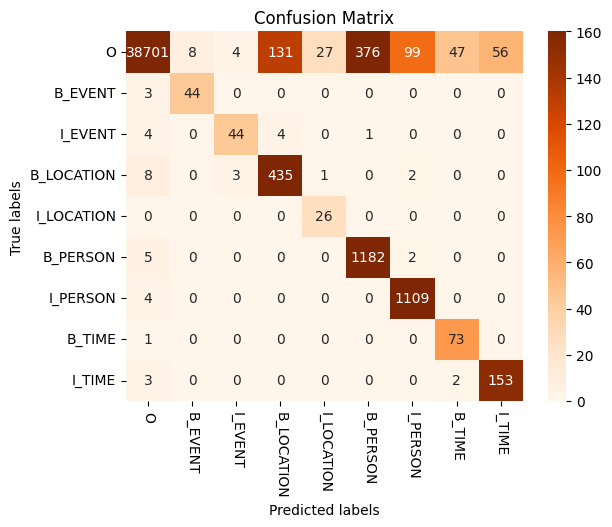

In [24]:
get_confusion_matrix(df_test)

In [25]:
get_misclassified_report(df_test, os.path.join(eval_dir, f"{experiment_name}-iter{LAST_ITER}-misclassified.xlsx"))


100%|██████████| 42558/42558 [00:02<00:00, 18190.90it/s]


In [26]:
get_correct_and_incorrect_classification(df_test, f"{experiment_name}-iterative-{LAST_ITER}")


100%|██████████| 42558/42558 [01:40<00:00, 425.40it/s]


In [27]:
df_test_base = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test_base["label"] = df_test_base["label"].apply(lambda x: x.replace("-", "_"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir , f"{experiment_name}-base"),
    df=df_test_base,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 258/258 [00:02<00:00, 88.61it/s]


In [28]:
get_overall_performance(df_test_base)
get_individual_label_score(df_test_base)

Accuracy: 0.9777715118191644
Precision: 0.9833594143118087
Recall: 0.9777715118191644
F1 Score: 0.9793957403456622


,precision,recall,f1-score,support
O,0.999041,0.977439,0.988122,39449.000000
B_EVENT,0.767857,0.914894,0.834951,47.000000
I_EVENT,0.833333,0.849057,0.841121,53.000000
B_LOCATION,0.712418,0.971047,0.821866,449.000000
I_LOCATION,0.464286,1.000000,0.634146,26.000000
B_PERSON,0.734887,0.981497,0.840475,1189.000000
I_PERSON,0.904568,0.996406,0.948268,1113.000000
B_TIME,0.496599,0.986486,0.660633,74.000000
I_TIME,0.690583,0.974684,0.808399,158.000000
accuracy,0.977772,0.977772,0.977772,0.977772
